In [1]:
# =============================================================================
# Zelle 01 – Setup & X_B-Generierung (Kundenauftrag + Maschinenkonfiguration)
# =============================================================================
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
N = 2000

# --- X_B1: Material (MFR) ---
material_mfr = np.clip(rng.normal(0.7, 0.2, N), 0.3, 1.5)

# --- X_B2: Ziel-Nennweite (kontinuierlich, rechtsschief) ---
dn_ziel = np.clip(rng.gamma(shape=2.2, scale=45, size=N) + 45, 50, 315)

# --- X_B3: Wandstaerke-Soll (DN-abhaengig + Kundenvarianz) ---
wandstaerke_soll = np.clip(1.0 + dn_ziel * 0.008 + rng.normal(0, 0.15, N), 0.8, 6.0)

# --- X_B4: Dickentoleranz (unabhaengig, kundenspezifisch) ---
dickentoleranz = np.clip(rng.uniform(0.05, 0.30, N), 0.05, 0.30)

# --- X_B5: Wandtyp (kategorial, ~73/27 wie Modell A) ---
wandtyp = rng.choice(["einwandig", "doppelwandig"], size=N, p=[0.734, 0.266])

# --- X_B6: Produktionsgeschwindigkeit-Soll (leicht DN-abhaengig, invers) ---
produktionsgeschwindigkeit_soll = np.clip(13 - dn_ziel * 0.018 + rng.normal(0, 2.2, N), 2, 17)

# --- X_B7: Ovalitaets-Anforderung (unabhaengig, kundenspezifisch) ---
ovalitaet_anforderung = np.clip(rng.uniform(0.3, 1.0, N), 0.3, 1.0)

df_b = pd.DataFrame({
    "material_mfr": material_mfr, "dn_ziel": dn_ziel, "wandstaerke_soll": wandstaerke_soll,
    "dickentoleranz": dickentoleranz, "wandtyp": wandtyp,
    "produktionsgeschwindigkeit_soll": produktionsgeschwindigkeit_soll,
    "ovalitaet_anforderung": ovalitaet_anforderung,
})

print(df_b.describe())
print(f"\nWandtyp-Verteilung:\n{df_b['wandtyp'].value_counts(normalize=True)}")

       material_mfr      dn_ziel  wandstaerke_soll  dickentoleranz  \
count   2000.000000  2000.000000       2000.000000     2000.000000   
mean       0.691102   143.858571          2.148795        0.174593   
std        0.195511    61.739670          0.514819        0.072674   
min        0.300000    50.000000          1.131757        0.050112   
25%        0.556000    96.089215          1.764290        0.110217   
50%        0.695507   132.313391          2.055759        0.176434   
75%        0.819885   176.673594          2.446877        0.235921   
max        1.335771   315.000000          3.816458        0.299867   

       produktionsgeschwindigkeit_soll  ovalitaet_anforderung  
count                      2000.000000            2000.000000  
mean                         10.395653               0.653398  
std                           2.458929               0.205098  
min                           2.459679               0.300035  
25%                           8.826559           

In [2]:
# =============================================================================
# Zelle 02 – Y_B-Generierung (KORRIGIERT: Vakuum/Innenluft als zwei separate,
# gleichzeitig wirkende Groessen statt hartem DN-Schwellenwert-Schalter)
# =============================================================================
# FACHLICHE KORREKTUR (nach Engineering-Feedback): urspruengliches Modell
# (harter DN>200-Schwellenwert fuer Formluft/Vakuum) war unrealistisch -
# der Uebergang ist in der Praxis fliessend und multifaktoriell (Material/
# Schmelzfestigkeit, Wanddicke, Liniengeschwindigkeit, Kuehlkonzept), nicht
# primaer durchmesserabhaengig. Vakuum und Innenluft wirken zudem
# GLEICHZEITIG gegeneinander (Vakuum zieht von aussen an die Kavitaet,
# Innenluft stabilisiert von innen gegen Kollaps/Ovalitaet) - kein Schalter
# zwischen zwei Modi, sondern zwei parallele Stellgroessen. DN bleibt als
# schwacher/sekundaerer Faktor erhalten, nicht mehr dominant/hart.
#
# Y_B waechst dadurch von 5 auf 6 Zielgroessen: kalibrierdruck/
# kalibriermechanismus entfallen, ersetzt durch vakuumniveau + innenluftdruck.
#
# Weitere Korrekturen (unveraendert aus vorheriger Iteration uebernommen):
# - Massetemperatur: Basiswert-Spanne erweitert (naeher an Modell-A-Bereich 195-230)
# - Kuehlwassertemperatur: unterer Bereich ergaenzt (naeher an Modell-A 8-25)
# - Duesenspalt: Material-abhaengiger Die-Swell-Faktor, verstaerktes Rauschen
# =============================================================================

# --- 1) Schneckendrehzahl: DN + Produktionsgeschwindigkeit ---
schneckendrehzahl_b = np.clip(
    8 + dn_ziel * 0.12 + produktionsgeschwindigkeit_soll * 1.8 + rng.normal(0, 3.0, N),
    10, 80
)

# --- 2) Massetemperatur: breiterer Basiswertebereich ---
basis_temperatur = 190 + material_mfr * 12 + (dn_ziel / 315) * 10
scherwaerme_zuschlag = (schneckendrehzahl_b - 40) * 0.30
massetemperatur_b = np.clip(basis_temperatur + scherwaerme_zuschlag + rng.normal(0, 4.0, N), 190, 232)

# --- 3) Duesenspalt: Wandstaerke-Soll + Material-Einfluss (Die-Swell) + DN, mehr Rauschen ---
die_swell_basis = 0.95 + (material_mfr - 0.7) * 0.08
duesenspalt_rauschen_staerke = 0.08 + dickentoleranz * 0.35
duesenspalt_b = np.clip(
    (wandstaerke_soll / die_swell_basis) + (dn_ziel - 150) * 0.0015 + rng.normal(0, duesenspalt_rauschen_staerke, N),
    0.35, 4.2
)

# --- 4) Vakuumniveau + Innenluftdruck: zwei separate, gleichzeitig wirkende Groessen ---
schmelzfestigkeit_proxy = 1.0 - (material_mfr - 0.3) / (1.3 - 0.3)  # 0=weich/MFR hoch, 1=fest/MFR niedrig

vakuumniveau_b = np.clip(
    40 + wandstaerke_soll * 15 + schmelzfestigkeit_proxy * 20 + dn_ziel * 0.05
    + rng.normal(0, 15, N),
    5, 130
)
innenluftdruck_b = np.clip(
    30 + (4.0 - wandstaerke_soll) * 12 + produktionsgeschwindigkeit_soll * 2.5
    + (1.0 - schmelzfestigkeit_proxy) * 15 - dn_ziel * 0.03
    + rng.normal(0, 12, N),
    5, 110
)

# --- 5) Kuehlwassertemperatur: breiterer, tieferer Wertebereich ---
kuehlwassertemperatur_b = np.clip(
    24 - (massetemperatur_b - 205) * 0.25 - produktionsgeschwindigkeit_soll * 0.5 + rng.normal(0, 2.2, N),
    5, 28
)

df_b["schneckendrehzahl"] = schneckendrehzahl_b
df_b["massetemperatur"] = massetemperatur_b
df_b["duesenspalt"] = duesenspalt_b
df_b["vakuumniveau"] = vakuumniveau_b
df_b["innenluftdruck"] = innenluftdruck_b
df_b["kuehlwassertemperatur"] = kuehlwassertemperatur_b
df_b["schmelzfestigkeit_proxy"] = schmelzfestigkeit_proxy  # Hilfsgroesse, zur Kontrolle mitgespeichert

print(df_b[["schneckendrehzahl", "massetemperatur", "duesenspalt", "vakuumniveau",
            "innenluftdruck", "kuehlwassertemperatur"]].describe())

       schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  \
count        2000.000000      2000.000000  2000.000000   2000.000000   
mean           44.127716       204.319682     2.256724     91.981956   
std             7.365883         5.798458     0.650303     17.768686   
min            23.343707       190.000000     0.903374     40.865681   
25%            39.013749       200.482562     1.781877     79.810774   
50%            43.729280       204.359936     2.143764     91.699970   
75%            48.573682       208.029083     2.634191    103.831124   
max            74.837590       226.528129     4.200000    130.000000   

       innenluftdruck  kuehlwassertemperatur  
count     2000.000000            2000.000000  
mean        79.878780              19.058264  
std         17.053956               2.909668  
min         11.511007               8.159216  
25%         68.767066              17.131432  
50%         81.022043              19.000304  
75%         92.001560 

Gespeichert: data/raw/model_b_raw.csv, Shape: (2000, 14)

Alle Spalten: ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur', 'schmelzfestigkeit_proxy']


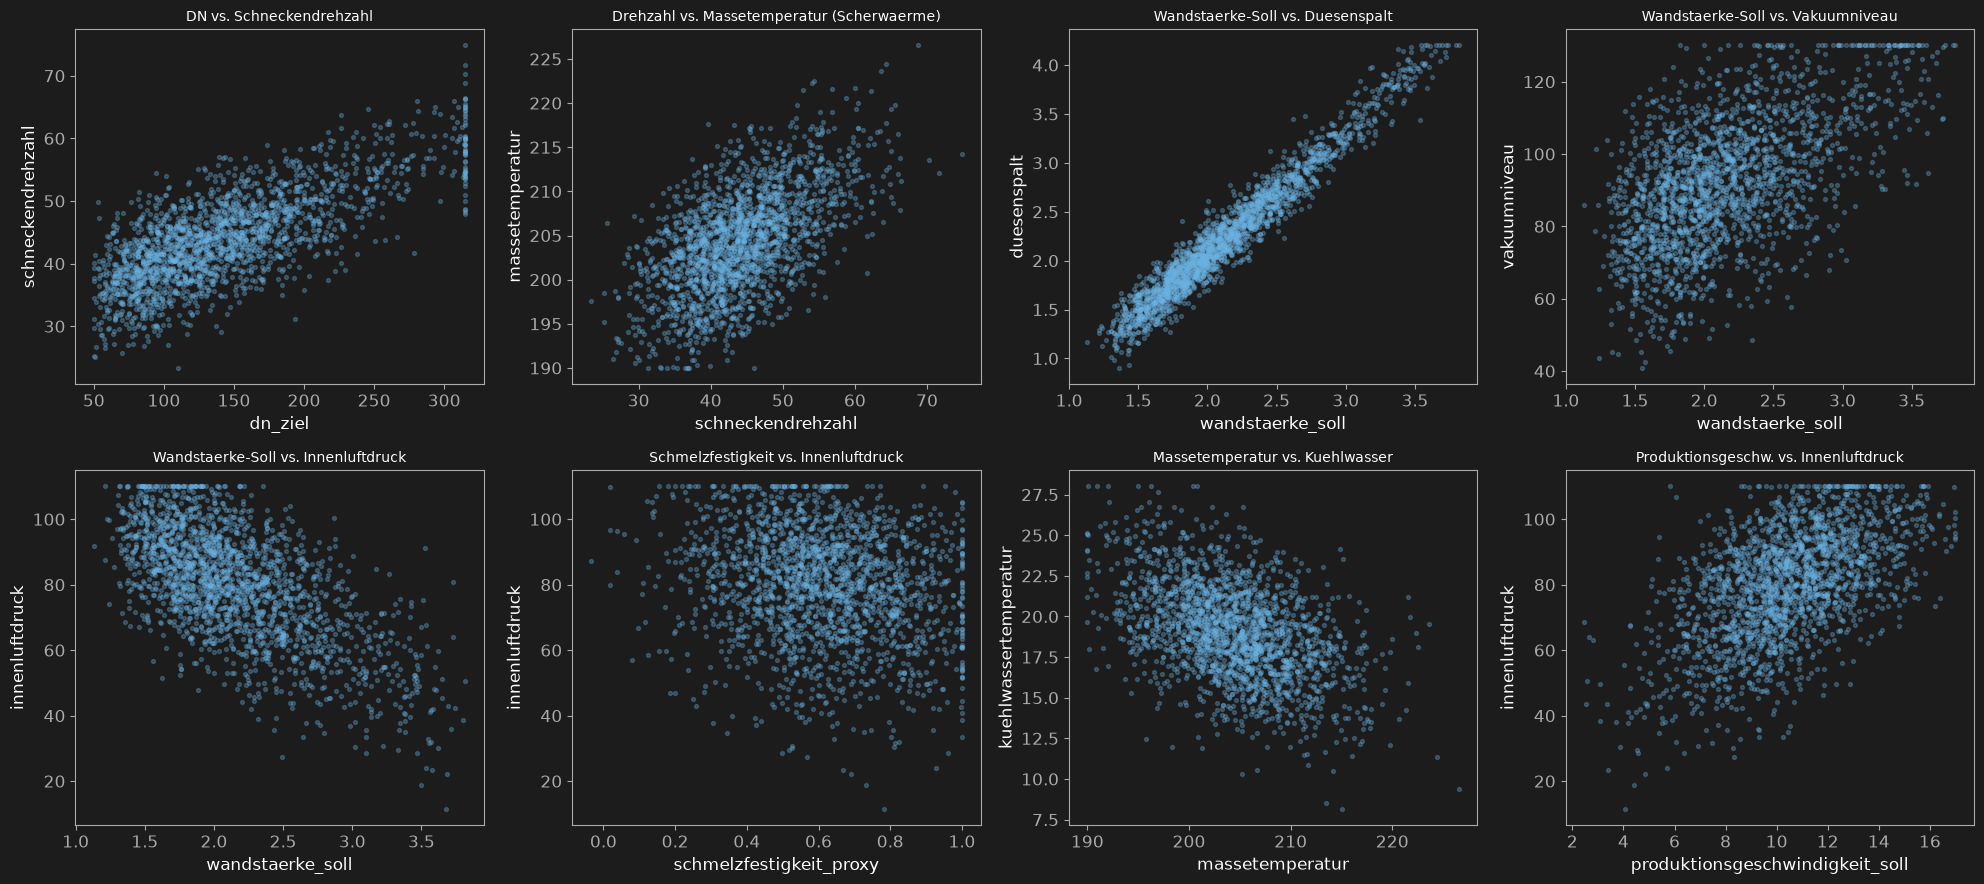

In [4]:
# =============================================================================
# Zelle 03 (KORRIGIERT) – Finale Speicherung + Plausibilitaets-Check
# =============================================================================
df_b.to_csv("../data/raw/model_b_raw.csv", index=False)
print(f"Gespeichert: data/raw/model_b_raw.csv, Shape: {df_b.shape}")
print(f"\nAlle Spalten: {df_b.columns.tolist()}")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

achsen_paare = [
    ("dn_ziel", "schneckendrehzahl", "DN vs. Schneckendrehzahl"),
    ("schneckendrehzahl", "massetemperatur", "Drehzahl vs. Massetemperatur (Scherwaerme)"),
    ("wandstaerke_soll", "duesenspalt", "Wandstaerke-Soll vs. Duesenspalt"),
    ("wandstaerke_soll", "vakuumniveau", "Wandstaerke-Soll vs. Vakuumniveau"),
    ("wandstaerke_soll", "innenluftdruck", "Wandstaerke-Soll vs. Innenluftdruck"),
    ("schmelzfestigkeit_proxy", "innenluftdruck", "Schmelzfestigkeit vs. Innenluftdruck"),
    ("massetemperatur", "kuehlwassertemperatur", "Massetemperatur vs. Kuehlwasser"),
    ("produktionsgeschwindigkeit_soll", "innenluftdruck", "Produktionsgeschw. vs. Innenluftdruck"),
]

for ax, (x, y, titel) in zip(axes.flat, achsen_paare):
    ax.scatter(df_b[x], df_b[y], alpha=0.3, s=8, color=COLOR_BLUE)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(titel, fontsize=10)

plt.tight_layout()
save_figure(fig, "../reports/figures/08_model_b_plausibilitaets_check.png")
plt.show()